<a href="https://colab.research.google.com/github/itsPratikHere/ML-Classification-Model/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORT LIBRARIES**

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATASET & DESCRIPTIVE ANALYSIS**


In [62]:
df = sns.load_dataset("titanic")

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [63]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**DATA CLEANING**

In [64]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [65]:
df.drop(columns=['deck'],inplace=True,errors="ignore")

df.drop(columns=['alive', 'who', 'adult_male', 'class', 'embark_town'], inplace=True,errors="ignore")


**HANDLING MISSING VALUES**

In [66]:
#Filling missing values in age with its Median
df["age"] = df["age"].fillna(df["age"].median())

#Filling missing embarked data with its Mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


**ENCODING**

In [67]:
#Label Encoding , Converting Categorical column Sex into binary
df["sex"] = df["sex"].map({'male':1,'female':0})

#One-Hot-Encoding , Creating Dummie Columns in Dataset and assigning boolean values
df = pd.get_dummies(df,columns=['embarked'],drop_first=True)


**TRAIN AND TEST SPLIT OF DATASET**

In [68]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived"])

y = df['survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


**MODEL TRAINING & PREDICTION**

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

# 1. Initialize the model with 100 trees
model = RandomForestClassifier(n_estimators=100,random_state=42)

# 2. Train the model using your training data
model.fit(X_train,y_train)

# 3. Make predictions on the test data
y_pred = model.predict(X_test)

#Comparison of Actual and Predicted
comparison = pd.DataFrame({"Actual":y_test[:10],"Predicted":y_pred[:10]})
print(comparison)



     Actual  Predicted
709       1          0
439       0          0
840       0          0
720       1          1
39        1          0
290       1          1
300       1          1
333       0          0
208       1          1
136       1          1


**MODEL EVALUATION**

In [70]:
#Accuracy Score
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy *100:.2f}%")

Accuracy: 81.01%


In [71]:
#Classification Report (Precision , Recall , F1 Score , Support)
report_dict = classification_report(y_test,y_pred,output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print(report_df.round(2))

              precision  recall  f1-score  support
0                  0.83    0.86      0.84   105.00
1                  0.79    0.74      0.76    74.00
accuracy           0.81    0.81      0.81     0.81
macro avg          0.81    0.80      0.80   179.00
weighted avg       0.81    0.81      0.81   179.00


**IMPORTANT FEATURE EVALUATION**

In [72]:
#Finding the importance value of each column in prediction
importances = pd.DataFrame({'feature':X.columns, 'importance':model.feature_importances_*100})
importances = importances.sort_values("importance",ascending=False)
print(importances.round(2))

      feature  importance
1         sex       27.98
5        fare       26.26
2         age       24.73
0      pclass        8.85
3       sibsp        4.31
4       parch        2.96
8  embarked_S        2.48
6       alone        1.45
7  embarked_Q        0.98


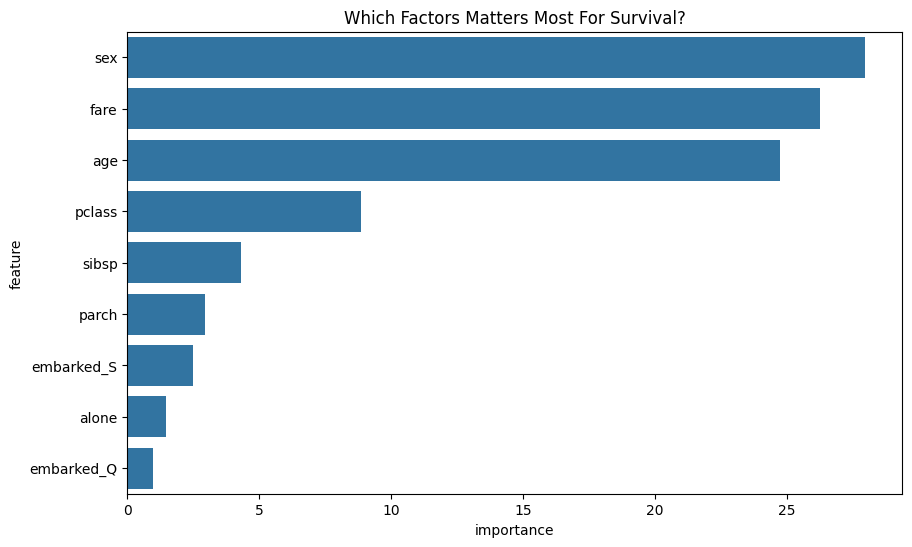

In [73]:
#Ploting important features
plt.figure(figsize=(10,6))
sns.barplot(x='importance',y='feature',data=importances)
plt.title("Which Factors Matters Most For Survival?")
plt.show()

**EVALUATION RESULT**

**Summary of Titanic Survival Model:Model:**

Random Forest Classifier ($n=100$)

Accuracy: 81.01%Key

 Insight: Gender and Fare (Social Class) were the primary drivers of survival, while the port of embarkation had a negligible effect.